## This notebook is for investigating relationship between difference distance measures, such as:

- Geodesic
- Walking
- Driving

In [1]:
import numpy as np
import geopandas as gpd
from shapely.geometry import Point, LineString, Polygon
from shapely.geometry import MultiPoint

import networkx as nx

In [2]:
# Load in different distance measures
datadir = '../'  # Up to "Data"
dist_path = datadir+'Distance Matrix Construction/'

city_code = 'dal'

In [3]:
# All the distance matrices to consider
# General format:
#    <distance type>_<service>_<modifiers or options>
dist_type_list = ['geodesic','walk']

# When we consider driving distances
#dist_type_list = ['geodesic','walk','drive_osm','drive_gmaps_TrafUnaware']

In [4]:
# Geography files
# - why provide full path: we have multiple resources. 
# - ZIP codes make more sense to provide in "resource ID agnostic" location
pfname =    datadir+'geo_export_872fcb6c-fbde-4264-ae77-8858a604ed0e.shp'
zipfname = datadir+ 'Zip/dal_tx_zip.shp'

In [5]:
dist_dict = dict()
dist_dict_vec = dict()
# Load in each matrix
for dist_type in dist_type_list:
    city_fname = f'{city_code}_{dist_type}_distance_data.npz'

    # use specifically the TIME matrix
    dist_dict[dist_type] = np.load(dist_path+city_fname)[f'{city_code}_{dist_type}_distance_seconds']

    # Turn into a vector suited for a scatter plot
    dist_dict_vec[dist_type] = np.reshape(dist_dict[dist_type],np.prod(np.size(dist_dict[dist_type])))

In [6]:
dist_dict_vec

{'geodesic': array([   0.        ,  448.13396216,  359.39807426,  492.68859629,
         837.41703444,  448.13396216,    0.        ,  352.67137588,
         533.48799006,  654.45512183,  359.39807426,  352.67137588,
           0.        ,  190.26628596,  973.27342036,  492.68859629,
         533.48799006,  190.26628596,    0.        , 1163.44030832,
         837.41703444,  654.45512183,  973.27342036, 1163.44030832,
           0.        ]),
 'walk': array([   0.        ,  747.18309859,  673.23943662, 1000.        ,
         930.28169014,  747.18309859,    0.        ,  471.83098592,
         791.54929577,  794.36619718,  673.23943662,  471.83098592,
           0.        ,  326.76056338, 1176.05633803, 1000.        ,
         791.54929577,  326.76056338,    0.        , 1496.47887324,
         930.28169014,  794.36619718, 1176.05633803, 1496.47887324,
           0.        ])}

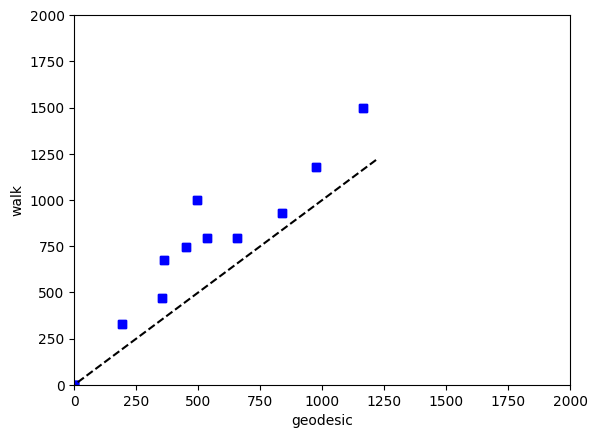

In [7]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

limit_axes = True

# For each pair of distance metrics provided, plot one vs. the other
for j1 in range(len(dist_dict)):
    for j2 in range(j1+1,len(dist_dict)):
        fig, axes = plt.subplots(1, 1)
        axes.plot(dist_dict_vec[dist_type_list[j1]], dist_dict_vec[dist_type_list[j2]], "bs")
        plt.xlabel(dist_type_list[j1])
        plt.ylabel(dist_type_list[j2])
        xlim = axes.get_xlim()
        ylim = axes.get_ylim()
        if xlim[1]<ylim[1]:
            axes.plot(xlim, xlim,'k--')
        else:
            axes.plot(ylim, ylim,'k--')

# It is a bit curious to see some walking distances as being LESS than geodesic. 
# What is going on there?
if limit_axes:
    axes.set_xlim([0,2000])
    axes.set_ylim([0,2000])

In [8]:
axes.set_xlim([0,1000])

(0.0, 1000.0)

In [9]:
axes.get_xlim()

(np.float64(0.0), np.float64(1000.0))